# 01 EDA

Exploracion inicial sobre una **muestra controlada de RAW**, pensada para responder exactamente lo que exige el enunciado antes de fijar reglas de limpieza y recien despues materializar la OBT.

## Que se valida en este notebook

- que la ingesta raw ya esta poblada y utilizable sin descargar la base completa
- que el target `fare_amount` tiene rango razonable y que la muestra deja visibles los problemas de calidad mas importantes
- que las variables candidatas para modelado pueden derivarse desde raw sin depender todavia de la OBT
- que las columnas de leakage existen en raw y quedan identificadas para excluirlas del contrato final
- que existen outliers relevantes que deben tratarse como parte natural del dominio y no como ruido accidental

## Por que este paso es importante

El objetivo del EDA no es rehacer limpieza masiva en pandas. Su funcion es **auditar RAW desde Snowflake**, observar distribuciones y defectos estructurales, y dejar evidencia de que las reglas del futuro `STAGING/OBT` salen de hallazgos concretos y no de decisiones arbitrarias.

Este notebook es deliberadamente **descriptivo global**: puede mirar una muestra representativa del periodo para entender distribuciones, nulos, outliers y estacionalidad. No debe aprender umbrales, encoders ni decisiones ajustadas con informacion de `validation` o `test`.

## Criterio de exito

Este notebook se considera correcto si demuestra que la muestra de `RAW.YELLOW_TRIPS_DEV`:

- refleja fielmente la estructura original de los viajes
- expone con claridad las columnas que luego deben excluirse por leakage
- mantiene una distribucion razonable del target y de `estimated_distance`
- deja identificados los puntos que deben vigilarse antes de construir la OBT final


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.ingestion import fetch_sample
from src.features.build_features import DISTANCE_COLUMN, LEAKAGE_COLUMNS, TARGET_COLUMN, build_candidate_modeling_frame, normalize_raw_taxi_frame
from src.utils.config import get_settings

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

settings = get_settings()
sample_limit = 10000
raw_sample = fetch_sample(
    f"SELECT * FROM {settings.raw_table}",
    sample_pct=1.0,
    limit=sample_limit,
    sample_seed=settings.eda_sample_seed,
    settings=settings,
)
sample_df = normalize_raw_taxi_frame(raw_sample)
candidate_df = build_candidate_modeling_frame(
    raw_sample,
    start_date=settings.data_start_date,
    end_date=settings.data_end_date,
)

assert not raw_sample.empty, 'La muestra raw del EDA esta vacia. Revisa setup/ingest.'
print('table =', settings.raw_table)
print('raw sample shape =', raw_sample.shape)
print('raw columns =', raw_sample.columns.tolist())
print('canonical columns =', sample_df.columns.tolist())
print('candidate rows after rules =', len(candidate_df))
sample_df.head()


table = DM_FINAL_PROJECT.ANALYTICS.OBT_TRIPS_DEV
sample shape = (10000, 12)
columns = ['pickup_datetime', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'passenger_count', 'trip_distance', 'pickup_location_id', 'dropoff_location_id', 'vendor_id', 'ratecode_id', 'fare_amount']


,pickup_datetime,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id,fare_amount
0,2025-01-14 19:16:05,19,2,1,0,1,2.60,229,75,1,1,12.8
1,2025-01-14 19:44:20,19,2,1,0,1,2.26,163,263,2,1,14.9
2,2025-01-14 19:43:52,19,2,1,0,1,1.21,90,170,2,1,10.7
3,2025-01-14 19:02:19,19,2,1,0,1,1.10,186,264,1,1,10.7
4,2025-01-14 19:30:54,19,2,1,0,1,1.58,186,186,2,1,12.8


In [3]:
required_cols = [
    'fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month', 'pickup_location_id', 'dropoff_location_id'
]
missing_cols = sorted(set(required_cols).difference(sample_df.columns))
assert not missing_cols, f'Faltan columnas esperadas en la OBT: {missing_cols}'
required_cols


['fare_amount',
 'trip_distance',
 'passenger_count',
 'pickup_hour',
 'pickup_dayofweek',
 'pickup_month',
 'pickup_location_id',
 'dropoff_location_id']

In [4]:
eda_summary = (
    pd.DataFrame({
        'dtype': sample_df.dtypes.astype(str),
        'nulls': sample_df.isna().sum(),
        'null_pct': (sample_df.isna().mean() * 100).round(2),
        'n_unique': sample_df.nunique(dropna=False),
    })
    .sort_values(['null_pct', 'n_unique'], ascending=[False, False])
)
eda_summary


,dtype,nulls,null_pct,n_unique
pickup_datetime,datetime64[ns],0,0.0,9966
trip_distance,float64,0,0.0,1353
fare_amount,float64,0,0.0,230
dropoff_location_id,int16,0,0.0,201
pickup_location_id,int16,0,0.0,158
pickup_hour,int8,0,0.0,24
pickup_dayofweek,int8,0,0.0,7
passenger_count,int8,0,0.0,6
ratecode_id,int8,0,0.0,6
is_weekend,int8,0,0.0,2


In [5]:
numeric_cols = [
    'fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month'
]
sample_df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
fare_amount,10000.0,17.851482,16.374540,0.01,4.40,5.8,12.10,58.3,73.0000,301.00
trip_distance,10000.0,3.144819,4.195620,0.01,0.28,0.5,1.63,12.6,20.0601,39.07
passenger_count,10000.0,1.296800,0.730043,1.00,1.00,1.0,1.00,3.0,5.0000,6.00
pickup_hour,10000.0,14.491800,5.554261,0.00,0.00,3.0,15.00,22.0,23.0000,23.00
pickup_dayofweek,10000.0,4.070900,1.802886,1.00,1.00,1.0,4.00,7.0,7.0000,7.00
pickup_month,10000.0,1.000000,0.000000,1.00,1.00,1.0,1.00,1.0,1.0000,1.00


In [6]:
quality_checks = pd.Series({
    'rows': len(sample_df),
    'target_le_zero': int((sample_df[TARGET_COLUMN] <= 0).sum()),
    f'{DISTANCE_COLUMN}_le_zero': int((sample_df[DISTANCE_COLUMN] <= 0).sum()),
    'passenger_out_of_range': int(((sample_df['passenger_count'] < 1) | (sample_df['passenger_count'] > 6)).sum()),
    'null_pickup_location': int(sample_df['pickup_location_id'].isna().sum()),
    'null_dropoff_location': int(sample_df['dropoff_location_id'].isna().sum()),
}, name="value")
quality_checks


rows                      10000
target_le_zero                0
trip_distance_le_zero         0
passenger_out_of_range        0
null_pickup_location          0
null_dropoff_location         0
Name: value, dtype: int64

In [7]:
forbidden_found = sorted(set(raw_sample.columns).intersection(LEAKAGE_COLUMNS))
print('Leakage columns found in sampled RAW:', forbidden_found)


Leakage columns found in sampled OBT: []


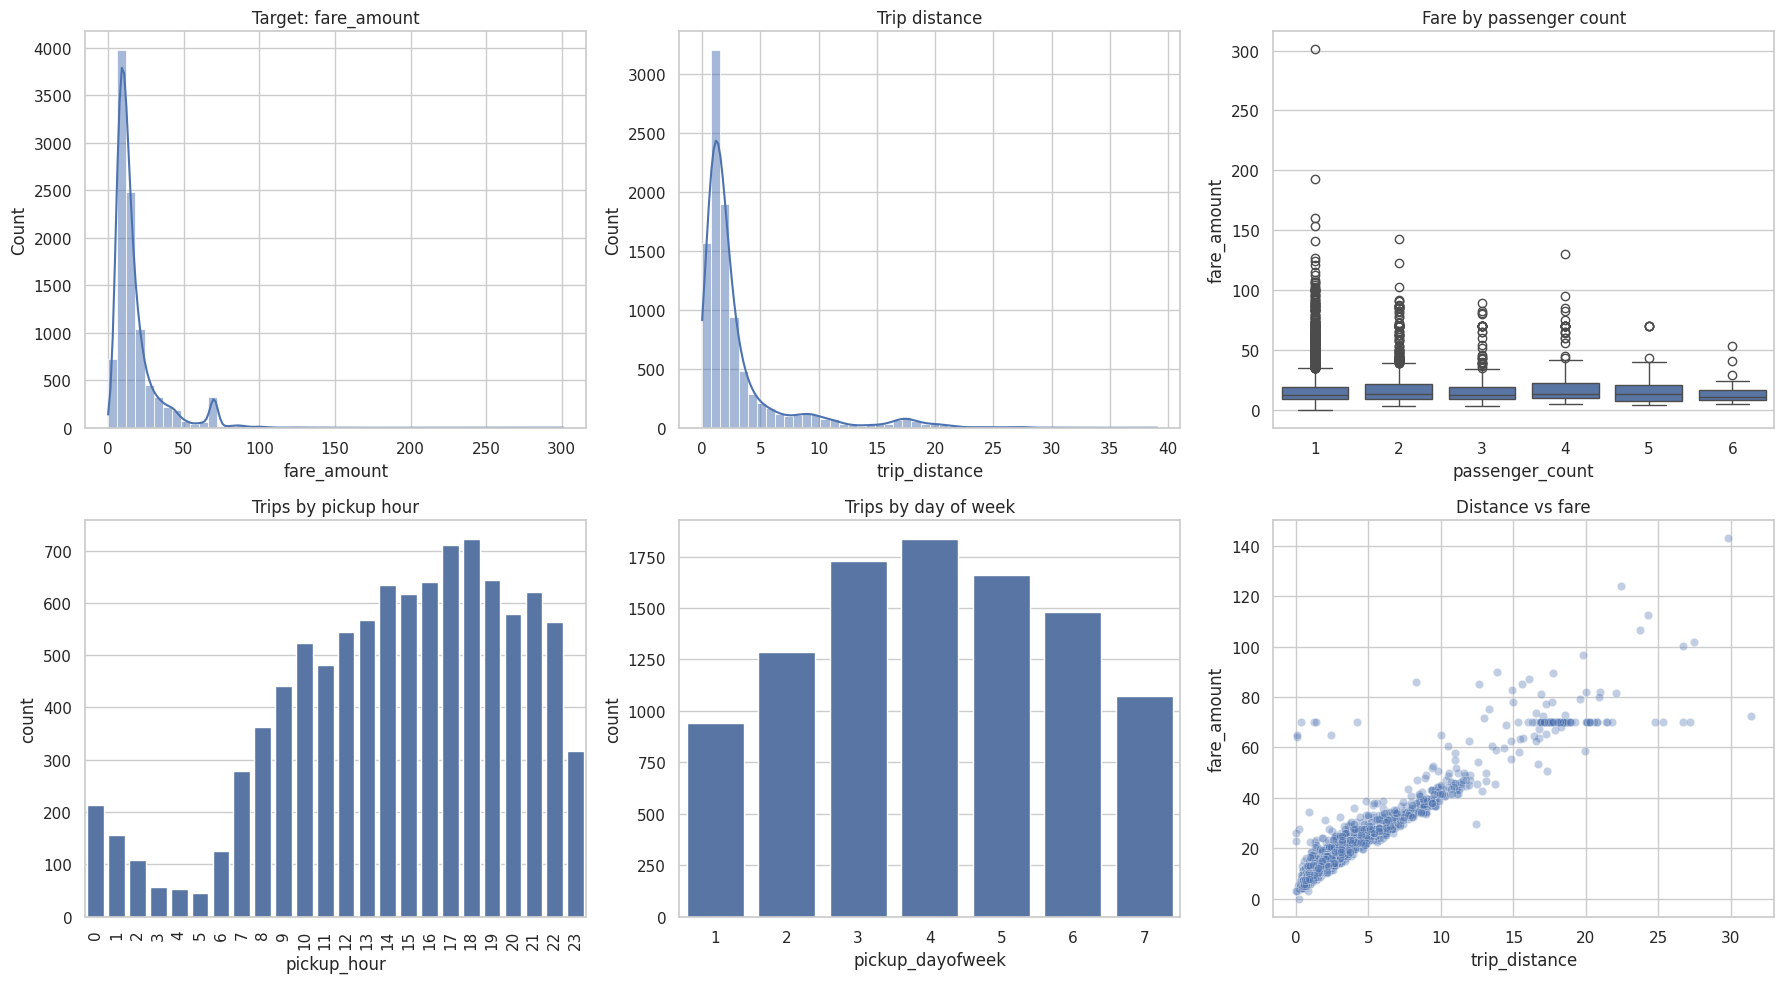

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(sample_df['fare_amount'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Target: fare_amount')
sns.histplot(sample_df[DISTANCE_COLUMN], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Estimated distance')
sns.boxplot(data=sample_df, x='passenger_count', y='fare_amount', ax=axes[0, 2])
axes[0, 2].set_title('Fare by passenger count')
sns.countplot(data=sample_df, x='pickup_hour', ax=axes[1, 0])
axes[1, 0].set_title('Trips by pickup hour')
axes[1, 0].tick_params(axis='x', rotation=90)
sns.countplot(data=sample_df, x='pickup_dayofweek', ax=axes[1, 1])
axes[1, 1].set_title('Trips by day of week')
plot_sample = sample_df.sample(min(len(sample_df), 2500), random_state=42)
sns.scatterplot(data=plot_sample, x=DISTANCE_COLUMN, y='fare_amount', alpha=0.35, ax=axes[1, 2])
axes[1, 2].set_title('Distance vs fare')
plt.tight_layout()


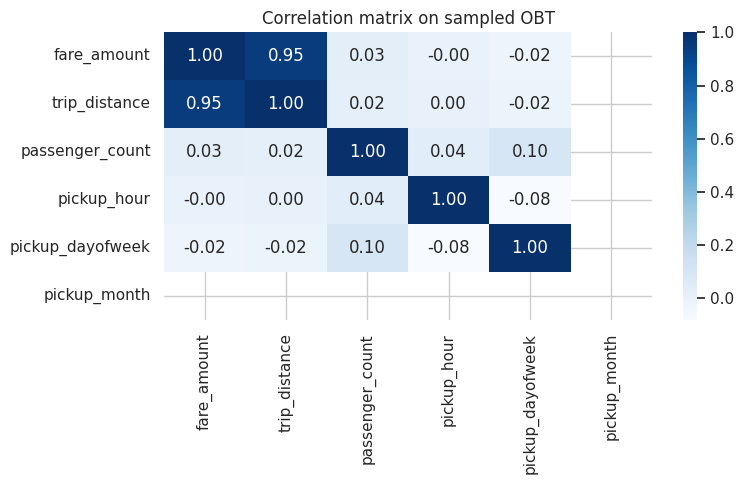

In [9]:
corr_cols = ['fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour', 'pickup_dayofweek', 'pickup_month']
corr_df = sample_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation matrix on sampled RAW (canonicalized)')
plt.tight_layout()


In [10]:
outlier_view = sample_df[['fare_amount', DISTANCE_COLUMN]].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).T
outlier_view


,count,mean,std,min,50%,95%,99%,99.5%,99.9%,max
fare_amount,10000.0,17.851482,16.37454,0.01,12.10,58.3,73.0000,87.901,120.60180,301.00
trip_distance,10000.0,3.144819,4.19562,0.01,1.63,12.6,20.0601,21.571,27.47011,39.07


## Conclusiones e interpretacion

- RAW no es todavia una tabla segura para modelado: contiene leakage y defectos que deben corregirse en `STAGING/OBT`.
- Los outliers mas relevantes suelen concentrarse en `fare_amount` y `estimated_distance`; se observan, se documentan y se tratan con criterio de negocio, no con eliminacion automatica sin justificacion.
- Si en esta etapa aparece leakage, nulos estructurales o rangos imposibles, la correccion debe quedar primero en reglas de limpieza y contrato de features antes de construir la OBT.
- Este notebook deja la evidencia base para defender que el modelado no nace directamente de raw: primero observa, luego define reglas y recien despues transforma.
